# ARIMAX Feature Block Comparison

Сравнивает ARIMAX/ARX модели для `log_return_1m`:

- Model 1: `ARIMAX(1,0,0) + BTC lags`
- Model 2: `ARIMAX(1,0,0) + aggression delta features`
- Model 3: `ARIMAX(1,0,0) + pressure features`
- Model 4: `ARIMAX(1,0,0) + BTC + aggression + pressure`
- Extra: `ARIMAX(3,0,0) + BTC + aggression + pressure`

Технически используется `statsmodels.tsa.ar_model.AutoReg(..., exog=...)`, то есть условная ARX-оценка. Для `d=0` это быстрый и практичный эквивалент ARIMAX(p,0,0) при переборе блоков признаков на большом минутном ряду.

Out-of-sample прогноз считается one-step-ahead: AR-лаги берут фактические прошлые `y`, exog берётся на текущую минуту `t`.

In [2]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from statsmodels.tsa.ar_model import AutoReg

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 160)

try:
    display
except NameError:
    display = print

## Settings

In [3]:
DATASET_PATH = Path("model_artifacts/adausdt_minute_log_return_temporal_dataset.parquet")
OUTPUT_DIR = Path("model_artifacts/arimax_feature_block_comparison")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = "log_return_1m"
TIME_COL = "timestamp"
DATE_COL = "date"

TRAIN_FRACTION = 0.8
MAX_ROWS = 500_000
USE_TAIL = True
SIGNIFICANCE_ALPHA = 0.05

# Ограничители на число exog-фичей по блоку. Это сохраняет модель устойчивой и быстрой.
BTC_FEATURE_LIMIT = 24
AGGRESSION_FEATURE_LIMIT = 35
PRESSURE_FEATURE_LIMIT = 35

assert DATASET_PATH.exists(), DATASET_PATH

## Select Exogenous Columns

In [4]:
pf = pq.ParquetFile(DATASET_PATH)
all_columns = pf.schema_arrow.names

def existing(cols):
    return [col for col in cols if col in all_columns]


btc_base = [
    "btc_features__btc_log_return",
    "btc_features__btc_zscore",
    "btc_features__btc_rolling_volatility",
]
btc_cols = [
    col for col in all_columns
    if col.startswith("btc_features__")
    and (
        "__lag_" in col
        or "__roll_mean_" in col
        or "__roll_std_" in col
        or "__ewm_mean_" in col
    )
]

aggression_seed = [
    "aggression_features__delta_base_norm",
    "aggression_features__delta_quote_norm",
]
aggression_cols = [
    col for col in all_columns
    if any(col.startswith(seed) for seed in aggression_seed)
    and (
        "__lag_" in col
        or "__roll_sum_" in col
        or "__roll_mean_" in col
        or "__roll_std_" in col
        or "__roll_abs_sum_" in col
        or "__ewm_mean_" in col
    )
]

pressure_seed = [
    "price_pressure__PI_total",
    "price_pressure__F_PI",
    "price_pressure__F_eff",
    "price_pressure__F_asymmetry",
    "price_pressure__VWAP_pos",
]
pressure_cols = [
    col for col in all_columns
    if any(col.startswith(seed) for seed in pressure_seed)
    and (
        "__lag_" in col
        or "__roll_mean_" in col
        or "__roll_std_" in col
        or "__ewm_mean_" in col
    )
]

print("available rows", pf.metadata.num_rows)
print("btc cols", len(btc_cols))
print("aggression cols", len(aggression_cols))
print("pressure cols", len(pressure_cols))
display(pd.DataFrame({
    "btc": pd.Series(btc_cols),
    "aggression": pd.Series(aggression_cols),
    "pressure": pd.Series(pressure_cols),
}).head(80))

available rows 3157859
btc cols 60
aggression cols 54
pressure cols 70


,btc,aggression,pressure
0,btc_features__btc_log_return__lag_1,aggression_features__delta_base_norm__lag_1,price_pressure__PI_total__lag_1
1,btc_features__btc_log_return__lag_2,aggression_features__delta_base_norm__lag_2,price_pressure__PI_total__lag_2
2,btc_features__btc_log_return__lag_3,aggression_features__delta_base_norm__lag_3,price_pressure__PI_total__lag_3
3,btc_features__btc_log_return__lag_5,aggression_features__delta_base_norm__lag_5,price_pressure__PI_total__lag_5
4,btc_features__btc_log_return__lag_10,aggression_features__delta_base_norm__lag_10,price_pressure__PI_total__lag_10
5,btc_features__btc_log_return__lag_15,aggression_features__delta_base_norm__lag_15,price_pressure__F_PI__lag_1
6,btc_features__btc_log_return__lag_30,aggression_features__delta_base_norm__lag_30,price_pressure__F_PI__lag_2
7,btc_features__btc_log_return__lag_60,aggression_features__delta_quote_norm__lag_1,price_pressure__F_PI__lag_3
8,btc_features__btc_zscore__lag_1,aggression_features__delta_quote_norm__lag_2,price_pressure__F_PI__lag_5
9,btc_features__btc_zscore__lag_2,aggression_features__delta_quote_norm__lag_3,price_pressure__F_PI__lag_10


Фичей может быть больше, чем нужно для ARX. Возьмём внутри каждого блока самые вариативные на рабочем хвосте ряда.

In [5]:
candidate_cols = sorted(set(btc_cols + aggression_cols + pressure_cols))
read_cols = [DATE_COL, TIME_COL, TARGET_COL] + candidate_cols

data = pd.read_parquet(DATASET_PATH, columns=read_cols)
data[TIME_COL] = pd.to_datetime(data[TIME_COL], utc=True)
data = data.sort_values(TIME_COL).dropna().reset_index(drop=True)

if MAX_ROWS is not None and len(data) > MAX_ROWS:
    data = data.tail(MAX_ROWS).reset_index(drop=True) if USE_TAIL else data.head(MAX_ROWS).reset_index(drop=True)

def top_by_variance(cols, limit):
    if not cols:
        return []
    variances = data[cols].var(numeric_only=True).sort_values(ascending=False)
    return variances.head(min(limit, len(variances))).index.tolist()

btc_model_cols = top_by_variance(btc_cols, BTC_FEATURE_LIMIT)
aggression_model_cols = top_by_variance(aggression_cols, AGGRESSION_FEATURE_LIMIT)
pressure_model_cols = top_by_variance(pressure_cols, PRESSURE_FEATURE_LIMIT)
combined_model_cols = list(dict.fromkeys(btc_model_cols + aggression_model_cols + pressure_model_cols))

print("data", data.shape, data[TIME_COL].min(), data[TIME_COL].max())
print("btc_model_cols", len(btc_model_cols))
print("aggression_model_cols", len(aggression_model_cols))
print("pressure_model_cols", len(pressure_model_cols))
print("combined_model_cols", len(combined_model_cols))

data (500000, 187) 2025-02-19 18:40:00+00:00 2026-02-01 23:59:00+00:00
btc_model_cols 24
aggression_model_cols 35
pressure_model_cols 35
combined_model_cols 94


## Fit And Compare ARIMAX Models

In [6]:
def one_step_arx_predictions(params, p, y_full, exog_full, start_idx, end_idx):
    names = list(params.index)
    const = float(params.get("const", 0.0))
    ar_coefs = []
    for lag in range(1, p + 1):
        key = f"y.L{lag}"
        if key not in params.index:
            matches = [name for name in names if name.endswith(f".L{lag}")]
            if not matches:
                raise KeyError(f"Cannot find AR coefficient for lag {lag}: {names}")
            key = matches[0]
        ar_coefs.append(float(params[key]))
    ar_coefs = np.asarray(ar_coefs)

    exog_names = [name for name in names if name not in {"const"} and not ".L" in name]
    exog_coefs = params[exog_names].to_numpy(dtype="float64") if exog_names else np.array([], dtype="float64")
    exog_name_to_idx = {name: idx for idx, name in enumerate(exog_full.columns)}
    exog_idx = [exog_name_to_idx[name] for name in exog_names]
    exog_values = exog_full.to_numpy(dtype="float64")

    preds = np.empty(end_idx - start_idx)
    for out_i, idx in enumerate(range(start_idx, end_idx)):
        lag_values = np.array([y_full[idx - lag] for lag in range(1, p + 1)], dtype="float64")
        exog_part = float(np.dot(exog_values[idx, exog_idx], exog_coefs)) if exog_idx else 0.0
        preds[out_i] = const + float(np.dot(ar_coefs, lag_values)) + exog_part
    return preds


def directional_metrics(y_true, pred):
    pred_sign = np.sign(pred)
    true_sign = np.sign(y_true)
    nonzero_true = true_sign != 0
    nonzero_both = (true_sign != 0) & (pred_sign != 0)
    return {
        "directional_accuracy": float((pred_sign == true_sign).mean()),
        "directional_accuracy_nonzero_true": float((pred_sign[nonzero_true] == true_sign[nonzero_true]).mean()),
        "directional_accuracy_nonzero_both": float((pred_sign[nonzero_both] == true_sign[nonzero_both]).mean()),
        "inverse_directional_accuracy_nonzero_true": float((pred_sign[nonzero_true] == -true_sign[nonzero_true]).mean()),
        "majority_directional_baseline_nonzero_true": float(max((true_sign[nonzero_true] > 0).mean(), (true_sign[nonzero_true] < 0).mean())),
        "true_zero_rate": float((true_sign == 0).mean()),
        "pred_zero_rate": float((pred_sign == 0).mean()),
        "pred_positive_rate": float((pred_sign > 0).mean()),
        "true_positive_rate": float((true_sign > 0).mean()),
    }


def fit_arimax_model(model_name, p, exog_cols):
    y = data[TARGET_COL].astype("float64").to_numpy()
    exog = data[exog_cols].astype("float64")
    split_idx = int(len(data) * TRAIN_FRACTION)

    train_y = y[:split_idx]
    test_y = y[split_idx:]
    train_exog = exog.iloc[:split_idx]

    result = AutoReg(train_y, lags=p, trend="c", exog=train_exog, old_names=False).fit()
    params = pd.Series(result.params, index=result.model.exog_names)
    pvalues = pd.Series(result.pvalues, index=result.model.exog_names)
    pred = one_step_arx_predictions(params, p, y, exog, split_idx, len(data))

    rmse = float(np.sqrt(np.mean((test_y - pred) ** 2)))
    mae = float(np.mean(np.abs(test_y - pred)))

    exog_pvalues = pvalues[[name for name in exog_cols if name in pvalues.index]]
    ar_pvalues = pvalues[[name for name in pvalues.index if ".L" in name]]

    row = {
        "model": model_name,
        "p": p,
        "exog_features": len(exog_cols),
        "aic": float(result.aic),
        "bic": float(result.bic),
        "hqic": float(result.hqic),
        "rmse": rmse,
        "mae": mae,
        "significant_ar_coefficients": int((ar_pvalues < SIGNIFICANCE_ALPHA).sum()),
        "total_ar_coefficients": int(len(ar_pvalues)),
        "significant_exog_coefficients": int((exog_pvalues < SIGNIFICANCE_ALPHA).sum()),
        "total_exog_coefficients": int(len(exog_pvalues)),
        "max_exog_pvalue": float(exog_pvalues.max()) if len(exog_pvalues) else np.nan,
        "min_exog_pvalue": float(exog_pvalues.min()) if len(exog_pvalues) else np.nan,
    }
    row.update(directional_metrics(test_y, pred))

    coef_df = pd.DataFrame({
        "model": model_name,
        "p": p,
        "term": params.index,
        "coefficient": params.to_numpy(),
        "pvalue": pvalues.to_numpy(),
        "significant": pvalues.to_numpy() < SIGNIFICANCE_ALPHA,
    })

    pred_df = pd.DataFrame({
        "timestamp": data[TIME_COL].iloc[split_idx:].to_numpy(),
        "model": model_name,
        "actual": test_y,
        "prediction": pred,
    })
    return row, coef_df, pred_df

In [7]:
model_specs = [
    {"model": "BTC_AR1", "p": 1, "cols": btc_model_cols},
    {"model": "Aggression_AR1", "p": 1, "cols": aggression_model_cols},
    {"model": "Pressure_AR1", "p": 1, "cols": pressure_model_cols},
    {"model": "Combined_AR1", "p": 1, "cols": combined_model_cols},
    {"model": "Combined_AR3", "p": 3, "cols": combined_model_cols},
]

metrics_rows = []
coef_frames = []
prediction_frames = []

for spec in model_specs:
    print(f"fit {spec['model']} with {len(spec['cols'])} exog features")
    row, coef_frame, pred_frame = fit_arimax_model(spec["model"], spec["p"], spec["cols"])
    metrics_rows.append(row)
    coef_frames.append(coef_frame)
    prediction_frames.append(pred_frame)

metrics_df = pd.DataFrame(metrics_rows).sort_values("rmse").reset_index(drop=True)
coef_df = pd.concat(coef_frames, ignore_index=True)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

display(metrics_df)
display(coef_df.head(30))

fit BTC_AR1 with 24 exog features
fit Aggression_AR1 with 35 exog features
fit Pressure_AR1 with 35 exog features
fit Combined_AR1 with 94 exog features
fit Combined_AR3 with 94 exog features


,model,p,exog_features,aic,bic,hqic,rmse,mae,significant_ar_coefficients,total_ar_coefficients,significant_exog_coefficients,total_exog_coefficients,max_exog_pvalue,min_exog_pvalue,directional_accuracy,directional_accuracy_nonzero_true,directional_accuracy_nonzero_both,inverse_directional_accuracy_nonzero_true,majority_directional_baseline_nonzero_true,true_zero_rate,pred_zero_rate,pred_positive_rate,true_positive_rate
0,Pressure_AR1,1,35,-4.046804e+06,-4.046390e+06,-4.046686e+06,0.001109,0.000730,1,1,29,35,0.584623,0.000000e+00,0.40058,0.470982,0.470982,0.529018,0.500165,0.14948,0.0,0.45862,0.42512
1,Combined_AR1,1,94,-4.049876e+06,-4.048819e+06,-4.049574e+06,0.001112,0.000734,1,1,72,94,0.996210,0.000000e+00,0.41523,0.488207,0.488207,0.511793,0.500165,0.14948,0.0,0.56280,0.42512
2,BTC_AR1,1,24,-4.035972e+06,-4.035677e+06,-4.035888e+06,0.001112,0.000736,1,1,17,24,0.718125,5.433303e-82,0.40741,0.479013,0.479013,0.520987,0.500165,0.14948,0.0,0.49065,0.42512
3,Combined_AR3,3,94,-4.050665e+06,-4.049586e+06,-4.050356e+06,0.001113,0.000735,3,3,72,94,0.916605,0.000000e+00,0.41366,0.486361,0.486361,0.513639,0.500165,0.14948,0.0,0.55906,0.42512
4,Aggression_AR1,1,35,-4.035780e+06,-4.035366e+06,-4.035662e+06,0.001115,0.000739,1,1,26,35,0.892056,1.966262e-63,0.41098,0.483210,0.483210,0.516790,0.500165,0.14948,0.0,0.53190,0.42512


,model,p,term,coefficient,pvalue,significant
0,BTC_AR1,1,const,-0.000039,1.014288e-02,True
1,BTC_AR1,1,y.L1,0.176949,0.000000e+00,True
2,BTC_AR1,1,btc_features__btc_zscore__lag_30,0.000001,6.365752e-01,False
3,BTC_AR1,1,btc_features__btc_zscore__lag_15,-0.000009,5.077356e-04,True
4,BTC_AR1,1,btc_features__btc_zscore__lag_10,-0.000005,4.262944e-02,True
5,BTC_AR1,1,btc_features__btc_zscore__lag_5,-0.000024,3.498208e-07,True
6,BTC_AR1,1,btc_features__btc_zscore__lag_2,-0.000012,1.127232e-02,True
7,BTC_AR1,1,btc_features__btc_zscore__lag_1,0.000074,6.759388e-53,True
8,BTC_AR1,1,btc_features__btc_zscore__lag_3,0.000031,2.169698e-10,True
9,BTC_AR1,1,btc_features__btc_zscore__lag_60,0.000007,7.340317e-03,True


## Plots

WindowsPath('model_artifacts/arimax_feature_block_comparison/arimax_block_metrics.png')

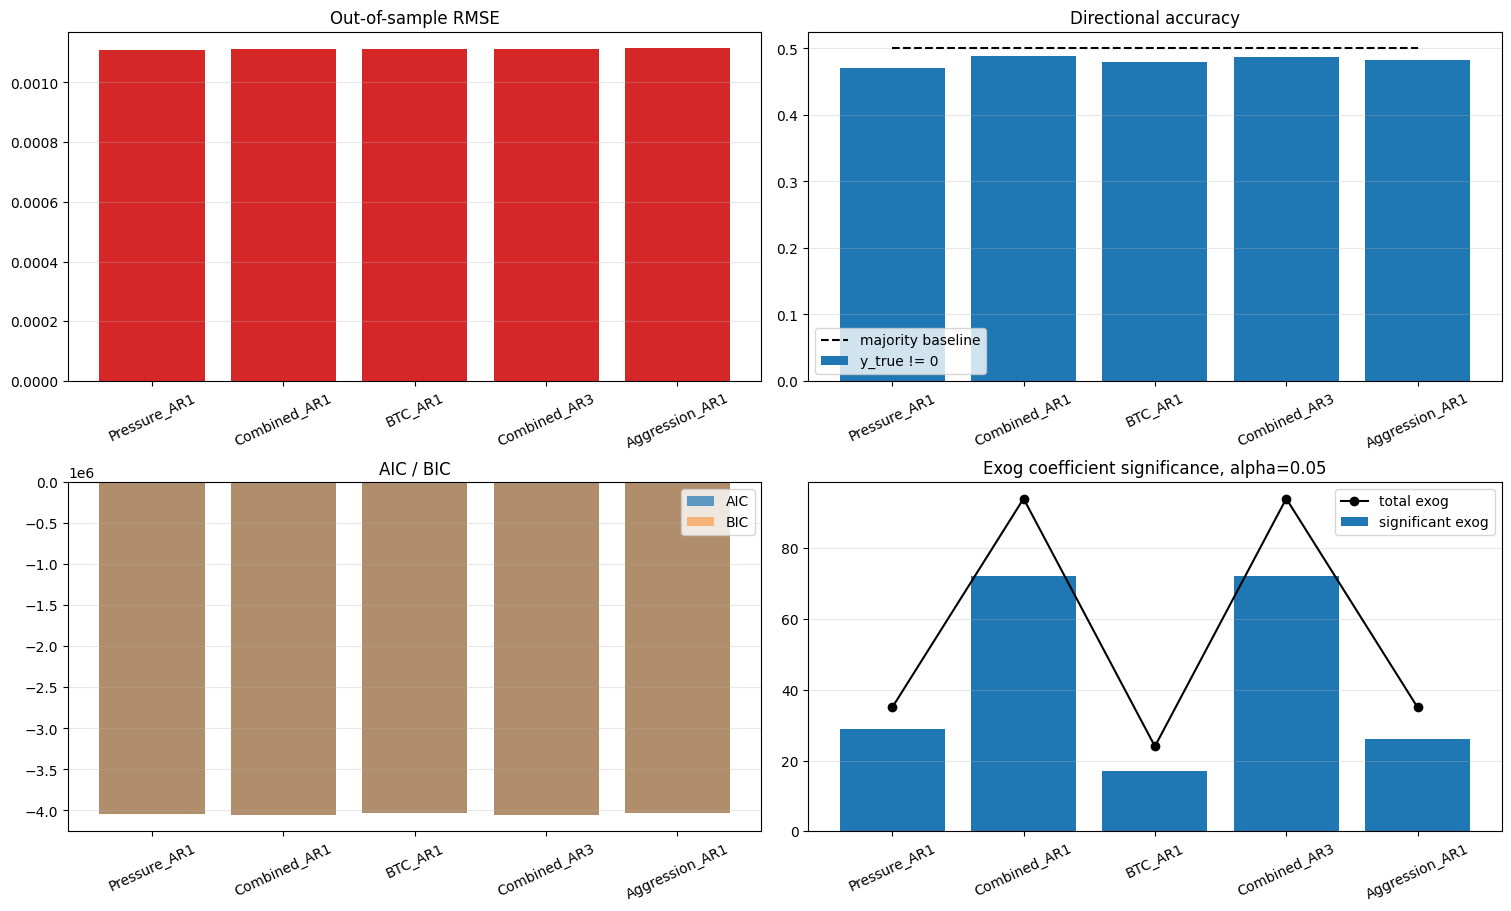

In [8]:
plt.style.use("default")
plot_order = metrics_df.sort_values("model")["model"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)

axes[0, 0].bar(metrics_df["model"], metrics_df["rmse"], color="tab:red")
axes[0, 0].set_title("Out-of-sample RMSE")
axes[0, 0].tick_params(axis="x", rotation=25)
axes[0, 0].grid(True, axis="y", alpha=0.3)

axes[0, 1].bar(metrics_df["model"], metrics_df["directional_accuracy_nonzero_true"], color="tab:blue", label="y_true != 0")
axes[0, 1].plot(metrics_df["model"], metrics_df["majority_directional_baseline_nonzero_true"], color="black", linestyle="--", label="majority baseline")
axes[0, 1].set_title("Directional accuracy")
axes[0, 1].tick_params(axis="x", rotation=25)
axes[0, 1].legend()
axes[0, 1].grid(True, axis="y", alpha=0.3)

axes[1, 0].bar(metrics_df["model"], metrics_df["aic"], alpha=0.7, label="AIC")
axes[1, 0].bar(metrics_df["model"], metrics_df["bic"], alpha=0.5, label="BIC")
axes[1, 0].set_title("AIC / BIC")
axes[1, 0].tick_params(axis="x", rotation=25)
axes[1, 0].legend()
axes[1, 0].grid(True, axis="y", alpha=0.3)

axes[1, 1].bar(metrics_df["model"], metrics_df["significant_exog_coefficients"], label="significant exog")
axes[1, 1].plot(metrics_df["model"], metrics_df["total_exog_coefficients"], marker="o", color="black", label="total exog")
axes[1, 1].set_title(f"Exog coefficient significance, alpha={SIGNIFICANCE_ALPHA}")
axes[1, 1].tick_params(axis="x", rotation=25)
axes[1, 1].legend()
axes[1, 1].grid(True, axis="y", alpha=0.3)

metrics_plot_path = OUTPUT_DIR / "arimax_block_metrics.png"
fig.savefig(metrics_plot_path, dpi=160)
metrics_plot_path

## Coefficient Significance Tables

In [9]:
top_significant_exog_df = (
    coef_df[(coef_df["term"] != "const") & (~coef_df["term"].str.contains(".L", regex=False))]
    .sort_values(["model", "pvalue"])
    .groupby("model")
    .head(25)
    .reset_index(drop=True)
)
display(top_significant_exog_df)

ar_coef_df = coef_df[coef_df["term"].str.contains(".L", regex=False)].copy()
display(ar_coef_df.sort_values(["model", "term"]))

,model,p,term,coefficient,pvalue,significant
0,Aggression_AR1,1,aggression_features__delta_base_norm__lag_5,4.108919e-01,1.966262e-63,True
1,Aggression_AR1,1,aggression_features__delta_quote_norm__lag_5,-4.108592e-01,2.013307e-63,True
2,Aggression_AR1,1,aggression_features__delta_quote_norm__lag_1,3.902258e-01,3.098711e-42,True
3,Aggression_AR1,1,aggression_features__delta_base_norm__lag_1,-3.900878e-01,3.309316e-42,True
4,Aggression_AR1,1,aggression_features__delta_quote_norm__roll_sum_15,1.152010e-01,3.546116e-33,True
...,...,...,...,...,...,...
119,Pressure_AR1,1,price_pressure__F_asymmetry__ewm_mean_5,-3.726386e-10,2.640408e-08,True
120,Pressure_AR1,1,price_pressure__F_asymmetry__lag_2,5.169285e-11,5.028036e-08,True
121,Pressure_AR1,1,price_pressure__PI_total__ewm_mean_15,5.690053e-07,3.283339e-07,True
122,Pressure_AR1,1,price_pressure__F_asymmetry__lag_10,-3.461363e-11,1.143161e-05,True


,model,p,term,coefficient,pvalue,significant
27,Aggression_AR1,1,y.L1,0.152165,0.000000e+00,True
1,BTC_AR1,1,y.L1,0.176949,0.000000e+00,True
101,Combined_AR1,1,y.L1,0.141709,0.000000e+00,True
197,Combined_AR3,3,y.L1,0.141456,0.000000e+00,True
198,Combined_AR3,3,y.L2,0.022541,1.064124e-23,True
199,Combined_AR3,3,y.L3,-0.061217,1.693259e-162,True
64,Pressure_AR1,1,y.L1,0.097947,0.000000e+00,True


## Save Outputs

In [10]:
metrics_df.to_csv(OUTPUT_DIR / "arimax_block_metrics.csv", index=False)
coef_df.to_csv(OUTPUT_DIR / "arimax_block_coefficients.csv", index=False)
top_significant_exog_df.to_csv(OUTPUT_DIR / "arimax_top_significant_exog.csv", index=False)
predictions_df.to_parquet(OUTPUT_DIR / "arimax_block_oos_predictions.parquet", index=False, compression="zstd")

feature_sets = {
    "BTC_AR1": btc_model_cols,
    "Aggression_AR1": aggression_model_cols,
    "Pressure_AR1": pressure_model_cols,
    "Combined_AR1": combined_model_cols,
    "Combined_AR3": combined_model_cols,
}
report = {
    "dataset": str(DATASET_PATH),
    "rows_used": int(len(data)),
    "max_rows": MAX_ROWS,
    "use_tail": USE_TAIL,
    "train_fraction": TRAIN_FRACTION,
    "feature_sets": feature_sets,
    "metrics": metrics_df.to_dict(orient="records"),
    "plots": {"metrics": str(metrics_plot_path)},
}
(OUTPUT_DIR / "arimax_block_report.json").write_text(json.dumps(report, indent=2), encoding="utf-8")

print("saved to", OUTPUT_DIR)

saved to model_artifacts\arimax_feature_block_comparison
